# Model Tuning: LightGBM + CV Analysis + Optuna  
 
**Цель текущего блокнота**: Оптимизация гиперпараметров и выбор наилучшей модели.  
**Следующий шаг**: Нейтрализация, ансамблирование и финальная подготовка прогнозов — в отдельном блокноте.  

Данные уже предварительно обработаны:  
- Удалены эры с пропусками - первые 249 эр  
- Purge=2 for Train
- Embargo=2 for Validation
- 772 признака из набора "Medium"  


**ПЛАН БЛОКНОТА**
0. Install Dependencies and Import
1. Loading Prepared Numerai Data
2. Era-Wise CV: Baseline  
3. Optuna: Study 1   
4. Era-Wise CV: Tuned 1  
5. Optuna: Study 2   
6. Era-Wise CV: Tuned Top-2 
7. Final Model


# 0. Install Dependencies and Import

In [1]:
# Install Dependencies
%pip install -q --upgrade numerapi numerai-tools optuna seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 33.4 MB/s eta 0:00:00


In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import random
from datetime import timedelta
import time
import warnings
from typing import Dict, List, Tuple, Optional, Any
from dataclasses import dataclass
import gc
from functools import partial

# Numerai
from numerapi import NumerAPI
from numerai_tools.scoring import numerai_corr, correlation_contribution, neutralize

# Files
import json
import os
import pickle
import cloudpickle
import shutil
from tqdm import tqdm

# ML
import lightgbm as lgb
from lightgbm.callback import early_stopping, log_evaluation

from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import make_scorer

import optuna
from optuna import Trial
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_contour
)

# Display Settings
pd.set_option("display.max_columns", 500)
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Inline plots
%matplotlib inline

# 1. Loading Prepared Numerai Data

In [3]:
# Uploading Prepared Datasets
train = pd.read_parquet("/content/drive/MyDrive/Colab Notebooks/Step_1/train_medium.parquet")
validation = pd.read_parquet("/content/drive/MyDrive/Colab Notebooks/Step_1/val_medium.parquet")

# Uploading metadata
with open('/content/drive/MyDrive/Colab Notebooks/Step_1/grouped_set_medium.pkl', 'rb') as f:
    dict_medium = pickle.load(f)

# Features List
full_feature_set = list(dict_medium['all'])

# print(f"Train: {train.shape}, Eras: {train['era'].min()}-{train['era'].max()}")
# print(f"Validation: {validation.shape}, Eras: {validation['era'].min()}-{validation['era'].max()}")
# print(f"Features: {len(full_feature_set)}")

In [4]:
# === DATA REDUCTION FOR FAST DEBUGGING ===
DEBUG = False  # False — full datasets
era_step = 10
n_features = 20


if DEBUG:
    # Filter Eras
    train_eras = sorted(train['era'].unique())
    selected_eras_train = train_eras[::era_step]
    train = train[train['era'].isin(selected_eras_train)].copy()
    
    val_eras = sorted(validation['era'].unique())
    selected_eras_val = val_eras[::era_step]
    validation = validation[validation['era'].isin(selected_eras_val)].copy()
    
    # Selecting the first `n_features`
    feature_set = full_feature_set[:n_features]

    # Column filtering
    cols_to_keep_train = ['era', 'target'] + feature_set
    cols_to_keep_val = ['era', 'target', 'meta_model'] + feature_set

    train = train[cols_to_keep_train]
    validation = validation[cols_to_keep_val]

    print(f"Используется признаков: {len(feature_set)}/{len(full_feature_set)}")
    
else:
    feature_set = full_feature_set
    print(f"Используется признаков: {len(feature_set)}/{len(full_feature_set)}")

summary = pd.DataFrame({
    'Dataset': ['Train', 'Validation'],
    'Rows': [train.shape[0], validation.shape[0]],
    'Columns': [train.shape[1], validation.shape[1]],
    'Start Era': [train['era'].min(), validation['era'].min()],
    'End Era': [train['era'].max(), validation['era'].max()],
    'Eras': [train['era'].nunique(), validation['era'].nunique()]
})

display(summary)

Используется признаков: 772/772


,Dataset,Rows,Columns,Start Era,End Era,Eras
0,Train,1627390,774,250,572,323
1,Validation,3823506,775,577,1192,616


In [5]:
# === GLOBALS & STORING RESULTS ===

NUM_STEP = 1
MODEL_TYPE = 'LGBMRegressor'
N_FOLDS_CV = 8
N_FOLDS_OPTUNA = 5

SEED  = 42
random.seed(SEED)
np.random.seed(SEED)

LGBMRegressor = partial(lgb.LGBMRegressor, verbosity=-1, device_type='gpu')

# Model Results
model_results = {}

COLS_META = ['num_step', 'model_type', 'model_name', 'target', 'estimate_type', 'time']
COLS_CORR = ['corr_mean', 'corr_sharpe', 'corr_std', 'corr_md']
COLS_MMC = ['mmc_mean', 'mmc_std', 'mmc_sharpe', 'mmc_md']
COLS_MISC = ['autocorr', 'feature_exposure', 'positive_eras', 'bi_mean']

COLS_FOLDS = COLS_CORR + ['positive_eras', 'best_iter']
COLS_CV = ['model_name', 'time'] + COLS_CORR + COLS_MISC

model_results_df = pd.DataFrame(columns=COLS_META + COLS_CORR + COLS_MMC + COLS_MISC + ['-'])
model_results_df

,num_step,model_type,model_name,target,estimate_type,time,corr_mean,corr_sharpe,corr_std,corr_md,mmc_mean,mmc_std,mmc_sharpe,mmc_md,autocorr,feature_exposure,positive_eras,bi_mean,-


## Help Functions

In [6]:
def compute_metrics_corr(df: pd.DataFrame, pred_col: str = 'prediction', target_col: str = 'target') -> dict:

    per_era_corr = df.groupby('era').apply(lambda g: numerai_corr(g[[pred_col]], g[target_col]))[pred_col]

    corr_mean = per_era_corr.mean() 
    corr_std = per_era_corr.std(ddof=0)
    corr_sharpe = corr_mean / corr_std
    corr_md = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()
    positive_eras = (per_era_corr > 0).mean()

    metrics_corr = {
        'corr_mean': corr_mean,
        'corr_std': corr_std,
        'corr_sharpe': corr_sharpe,
        'corr_md': corr_md,
        'positive_eras': positive_eras,
    }

    return metrics_corr


def compute_metrics_mmc(df: pd.DataFrame, pred_col: str = 'prediction', meta_col: str = 'meta_model', target_col: str = 'target') -> dict:

    df = df.dropna(subset=[pred_col, meta_col, target_col, 'era'])
    
    per_era_mmc = df.groupby('era').apply(lambda g: correlation_contribution(g[[pred_col]], g[meta_col], g[target_col]))[pred_col]

    mmc_mean = per_era_mmc.mean()
    mmc_std = per_era_mmc.std(ddof=0)
    mmc_sharpe = mmc_mean / mmc_std  # if mmc_std != 0 else 0.0
    mmc_md = ((per_era_mmc.cumsum().expanding(min_periods=1).max() - per_era_mmc.cumsum()).max())

    metrics_mmc = {
        'mmc_mean': mmc_mean,
        'mmc_std': mmc_std,
        'mmc_sharpe': mmc_sharpe,
        'mmc_md': mmc_md,
    }

    return metrics_mmc

# Межэровая автокорреляция (GPT)
def compute_autocorr_inter(df: pd.DataFrame, pred_col: str = 'prediction') -> float:
    
    pred_by_era = df.groupby('era')[pred_col].mean().sort_index()  # Агрегируем предсказания по эре
    corr = pred_by_era.corr(pred_by_era.shift(1), method='spearman')  # Сдвиг: era_t vs era_{t+1}  
    
    return round(corr, 4) if pd.notna(corr) else np.nan

# Внутриэровая автокорреляция
def compute_autocorr_intra(df: pd.DataFrame, pred_col: str = 'prediction') -> Dict[str, float]:
   
    def autocorr_era(group):
        return group[pred_col].corr(group[pred_col].shift(1))
    
    autocorrs = df.groupby('era', group_keys=True).apply(autocorr_era)
    autocorr_mean = autocorrs.mean()
    
    return autocorr_mean

def compute_feature_exposure(df: pd.DataFrame, pred_col: str, feature_set: List[str]) -> Dict[str, float]:

    X, y = df[feature_set], df[pred_col]
    
    return X.corrwith(y).abs().mean()

### Metrics

In [ ]:
# def compute_metrics_corr(df: pd.DataFrame, pred_col: str = 'prediction', target_col: str = 'target') -> dict:

#     per_era_corr = df.groupby('era').apply(lambda g: numerai_corr(g[[pred_col]], g[target_col]))

#     corr_mean = per_era_corr.mean() 
#     corr_std = per_era_corr.std(ddof=0)
#     corr_sharpe = corr_mean / corr_std
#     corr_md = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()
#     positive_eras = (per_era_corr > 0).mean()

#     metrics_corr = {
#         'corr_mean': corr_mean,
#         'corr_std': corr_std,
#         'corr_sharpe': corr_sharpe,
#         'corr_md': corr_md,
#         'positive_eras': positive_eras,
#         # "n_eras": len(per_era_corr)
#     }

#     return {k: round(float(v), 4) for k, v in metrics_corr.items()}


In [ ]:
def compute_metrics_mmc(df: pd.DataFrame, pred_col: str = 'prediction', meta_col: str = 'meta_model', target_col: str = 'target') -> dict:

    # Удаляем NaN и группируем по эрам
    df = df.dropna(subset=[pred_col, meta_col, target_col, 'era'])
    
    per_era_mmc = df.groupby('era').apply(lambda g: correlation_contribution(g[[pred_col]], g[meta_col], g[target_col]))

    mmc_mean = per_era_mmc.mean()
    mmc_std = per_era_mmc.std(ddof=0)
    mmc_sharpe = mmc_mean / mmc_std  # if mmc_std != 0 else 0.0
    mmc_md = ((per_era_mmc.cumsum().expanding(min_periods=1).max() - per_era_mmc.cumsum()).max())

    metrics_mmc = {
        'mmc_mean': mmc_mean,
        'mmc_std': mmc_std,
        'mmc_sharpe': mmc_sharpe,
        'mmc_md': mmc_md,
    }

    return {k: round(float(v), 4) for k, v in metrics_mmc.items()}


In [ ]:
def compute_autocorr(df: pd.DataFrame, pred_col: str = 'prediction') -> float:
    """
    Вычисляет автокорреляцию предсказаний по эрам: корреляция между pred[era_t] и pred[era_{t+1}].
    Возвращает: автокорреляция с лагом 1 (по эрам), или NaN если невозможно посчитать
    '0.05-0.2' – Хороший баланс стабильности и адаптивности 
    """
    pred_by_era = df.groupby('era')[pred_col].mean().sort_index()  # Агрегируем предсказания по эре
    corr = pred_by_era.corr(pred_by_era.shift(1), method='spearman')  # Сдвиг: era_t vs era_{t+1}  
    
    return round(corr, 4) if pd.notna(corr) else np.nan

# autocorr = compute_autocorr(oof)
# print(f"Autocorrelation (lag-1): {autocorr}")


In [9]:
def compute_feature_exposure(df: pd.DataFrame, features_df: pd.DataFrame, pred_col: str = 'prediction') -> float:

    pred = df[pred_col].rank(pct=True, method="first")  # Получаем ранжированные предсказания (Series)
    feats = features_df.rank(pct=True, method="first")  # Ранжируем признаки (DataFrame)
    corrs = feats.corrwith(pred, method='pearson')  # Корреляция каждого признака с предсказаниями
    
    return round(float(corrs.abs().mean()), 4)  # Среднее абсолютных корреляций

# final_feature_exposure = compute_feature_exposure(df=oof, features_df=train[FEATURES], pred_col=PREDICTION)
# final_feature_exposure

### Plot

In [7]:
# Plot: CV Metrics per Fold
def plot_cv_metrics(fold_results_df: dict, cols_folds=COLS_FOLDS, title: str = "CV Metrics per Fold"):
    
    df_plot = fold_results_df.iloc[:-1].copy()  # Удаляем агрегированную строку
    df_plot['fold'] = df_plot['fold'].astype(int)  # Преобразуем столбец 'fold' в int
    df_plot = df_plot.set_index('fold')  # Устанавливаем 'fold' как индекс
    

    axes = df_plot[COLS_FOLDS].plot.bar(
        subplots=True,
        figsize=(14, 3),
        layout=(1, len(COLS_FOLDS)),
        sharex=False,
        color="purple",
        legend=False,
        alpha=0.5,
        title=""
    )

    for ax in axes.flat:
        ax.grid(True, axis='y', alpha=0.5, linestyle='--')
        ax.set_xlabel("")
        ax.set_yticklabels([]) 

    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

# plot_cv_metrics(fold_results_df, COLS_FOLDS)


In [8]:
# Plot: Correlation by Era
def plot_correlation_by_era(df: pd.DataFrame, pred_col: str = "prediction", target_col: str = "target"):

    # Вычисляем корреляцию по эрам
    per_era_corr = df.groupby("era").apply(lambda x: numerai_corr(x[[pred_col]], x[target_col]))[pred_col]
    mean_corr = per_era_corr.mean()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # === Validation CORR by Era ===
    ax1 = axes[0]
    ax1.bar(range(len(per_era_corr)), per_era_corr.values, color="darkorange", alpha=0.7)
    ax1.axhline(mean_corr, color="black", linestyle="--", linewidth=0.5,
                label=f"Mean = {mean_corr:.3f}")
    ax1.axhline(0, color="darkorange", linewidth=0.8)
    ax1.set_title("CORR by Era", fontsize=10, fontweight="bold")
    ax1.set_xlabel("Eras")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # === Cumulative CORR ===
    ax2 = axes[1]
    cumcorr = per_era_corr.cumsum()
    ax2.plot(range(len(cumcorr)), cumcorr.values, color="darkorange", linewidth=2, label="Cumulative CORR")
    ax2.set_title("Cumulative CORR by Era", fontsize=10, fontweight="bold")
    ax2.set_xlabel("Eras")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# plot_correlation_by_era(oof, pred_col="prediction")

In [9]:
def plot_mmc_by_era(df: pd.DataFrame, pred_col: str = 'prediction', meta_col: str = 'meta_model', target_col: str = 'target'):

    df = df.dropna(subset=[pred_col, meta_col, target_col, 'era'])

    per_era_mmc = df.groupby('era').apply(lambda g: correlation_contribution(g[[pred_col]], g[meta_col], g[target_col]))[pred_col]
    mean_mmc = per_era_mmc.mean()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # === MMC by Era ===
    ax1 = axes[0]
    ax1.bar(range(len(per_era_mmc)), per_era_mmc.values, color='purple', alpha=0.7)
    ax1.axhline(mean_mmc, color='black', linestyle='--', linewidth=0.8, label=f"Mean MMC = {mean_mmc:.4f}")
    ax1.axhline(0, color='black', linewidth=0.5)
    ax1.set_title("MMC by Era", fontsize=10, fontweight="bold")
    ax1.set_xlabel("Eras")
    ax1.set_ylabel("MMC")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # === Cumulative MMC ===
    ax2 = axes[1]
    cummmc = per_era_mmc.cumsum()
    ax2.plot(range(len(cummmc)), cummmc.values, color='purple', linewidth=2, label="Cumulative MMC")
    ax2.set_title("Cumulative MMC by Era", fontsize=10, fontweight="bold")
    ax2.set_xlabel("Eras")
    ax2.set_ylabel("Cumulative MMC")
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# plot_mmc_by_era(validation, pred_col="prediction", meta_col="meta_model", target_col="target")

In [10]:
# Plot: Mean Feature Importance
def plot_feature_importance(importance_df: pd.DataFrame, top_k: int = 20):

    # Выбираем топ-k признаков и разворачиваем для отображения
    top_imp = importance_df.head(top_k).iloc[::-1]

    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    ax.barh(top_imp["feature"], top_imp["importance"], color="steelblue", edgecolor="black", height=0.7)

    ax.set_title("Mean Feature Importance (Gain)", fontsize=14, fontweight="bold")#, pad=15)
    ax.set_ylabel("Feature")
    ax.grid(axis="x", alpha=0.5)

    plt.tight_layout()
    plt.show()

# plot_feature_importance(importance_df, top_k=20)

In [11]:
# Plot: Prediction Distributions & Scatter
def plot_prediction_target(
    df: pd.DataFrame,
    target_col: str = 'target',
    pred_col: str = 'prediction',
    bins: int = 10,
):

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # === Distributions Prediction & Target ===
    ax1 = axes[0]
    sns.histplot(
        df[pred_col], bins=bins, ax=ax1, alpha=0.6,
        label=f"Prediction", color='blue', stat='density'
    ) #, kde=True 
    sns.histplot(
        df[target_col], bins=bins, ax=ax1, alpha=0.6,
        label=f"Target", color='red', stat='density'
    ) #, kde=True
    # ax1.set_title(": Distribution")
    ax1.set_xlabel("Value")
    ax1.set_ylabel("Density")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # === Scatter Plot Prediction vs Target ===
    ax2 = axes[1]
    ax2.scatter(
        df[target_col], df[pred_col],
        alpha=0.4, s=5, color='purple', edgecolor=None
    )
    ax2.set_xlabel("Target")
    ax2.set_ylabel("Prediction")
    # ax2.set_title("Prediction vs Target: Scatter Plot")
    ax2.grid(True, alpha=0.3)

    lims = [
        np.min([ax2.get_xlim(), ax2.get_ylim()]),
        np.max([ax2.get_xlim(), ax2.get_ylim()]),
    ]
    ax2.plot(lims, lims, linestyle="--", color="black", alpha=0.5, label="y=x")
    ax2.legend(loc="lower right")

    fig.suptitle("Prediction vs Target", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

# plot_prediction_distributions(df=oof, target_col="target", pred_col="prediction")


### Validation

In [12]:
def train_validation( 
        train_df: pd.DataFrame,
        val_df: pd.DataFrame,
        params: dict,
        model_name: str,
        feature_set: List[str] = feature_set,
        target_col: str = 'target',
        pred_col: str = 'prediction',
        meta_col: str = 'meta_model',
    ) -> dict:

    start_time = time.perf_counter()

    # Обучение модели
    model = LGBMRegressor(**params, random_state=SEED)
    model.fit(train_df[feature_set], train_df[target_col])

    # Прогноз на validation
    val_pred = model.predict(val_df[feature_set])
    val_df = val_df.copy()
    val_df[pred_col] = val_pred

    # Время выполнения
    elapsed_time = time.perf_counter() - start_time
    elapsed_str = str(timedelta(seconds=int(elapsed_time)))

    # Вычисление метрик
    metrics_corr = compute_metrics_corr(val_df, pred_col=pred_col, target_col=target_col)
    metrics_mmc = compute_metrics_mmc(val_df, pred_col=pred_col, meta_col=meta_col, target_col=target_col)
    
    autocorr_inter = compute_autocorr_inter(val_df, pred_col=pred_col)
    autocorr_intra = compute_autocorr_intra(val_df, pred_col=pred_col)

    feature_exposure = compute_feature_exposure(val_df, pred_col=pred_col, feature_set=feature_set)
    

    # === Feature Importance per Fold ===
    importances = model.booster_.feature_importance(importance_type='gain')
    importance_series = pd.Series(importances, index=feature_set, name="gain")

    all_metrics = {
        'corr_mean': metrics_corr['corr_mean'],
        'corr_std': metrics_corr['corr_std'],
        'corr_sharpe': metrics_corr['corr_sharpe'],
        'corr_md': metrics_corr['corr_md'],
        'mmc_mean': metrics_mmc['mmc_mean'],
        'mmc_std': metrics_mmc['mmc_std'],
        'mmc_sharpe': metrics_mmc['mmc_sharpe'],
        'mmc_md': metrics_mmc['mmc_md'],
        'feature_exposure': feature_exposure,
        'autocorr_intra': autocorr_intra,
        'autocorr_inter': autocorr_inter,
        'positive_eras': metrics_corr['positive_eras'],
    }

    all_metrics = pd.Series(all_metrics)

    return {
        'model_name': model_name,
        'target': target_col,
        'estimate_type': 'train_val',
        'time': elapsed_str,
        'metrics': all_metrics,
        'params': params,
        'fold_results_df': None,
        'oof': val_df,
        'importance_df': importance_series
    }

In [13]:
# def train_validation( 
#         train_df: pd.DataFrame,
#         val_df: pd.DataFrame,
#         params: dict,
#         model_name: str,
#         feature_set: List[str] = feature_set,
#         target_col: str = 'target',
#         pred_col: str = 'prediction',
#         meta_col: str = 'meta_model',
#     ) -> dict:

#     start_time = time.perf_counter()

#     # Обучение модели
#     model = LGBMRegressor(**params, random_state=SEED)
#     model.fit(train_df[feature_set], train_df[target_col])

#     # Прогноз на validation
#     val_pred = model.predict(val_df[feature_set])
#     val_df = val_df.copy()
#     val_df[pred_col] = val_pred

#     # Время выполнения
#     elapsed_time = time.perf_counter() - start_time
#     elapsed_str = str(timedelta(seconds=int(elapsed_time)))

#     # Вычисление метрик
#     metrics_corr = compute_metrics_corr(val_df, pred_col=pred_col, target_col=target_col)
#     metrics_mmc = compute_metrics_mmc(val_df, pred_col=pred_col, meta_col=meta_col, target_col=target_col)
    
#     autocorr = compute_autocorr(val_df, pred_col=pred_col)

#     feature_exposure = compute_feature_exposure(val_df, features_df=val_df[feature_set], pred_col=pred_col)

#     # === Feature Importance per Fold ===
#     importances = model.booster_.feature_importance(importance_type='gain')
#     importance_series = pd.Series(importances, index=feature_set, name="gain")

#     all_metrics = {
#         'corr_mean': metrics_corr['corr_mean'],
#         'corr_std': metrics_corr['corr_std'],
#         'corr_sharpe': metrics_corr['corr_sharpe'],
#         'corr_md': metrics_corr['corr_md'],
#         'mmc_mean': metrics_mmc['mmc_mean'],
#         'mmc_std': metrics_mmc['mmc_std'],
#         'mmc_sharpe': metrics_mmc['mmc_sharpe'],
#         'mmc_md': metrics_mmc['mmc_md'],
#         'autocorr': autocorr,
#         'feature_exposure': feature_exposure,
#         'positive_eras': metrics_corr['positive_eras'],
#     }

#     all_metrics = pd.Series(all_metrics)

#     return {
#         'model_name': model_name,
#         'target': target_col,
#         'estimate_type': 'train_val',
#         'time': elapsed_str,
#         'metrics': all_metrics,
#         'params': params,
#         'fold_results_df': None,
#         'oof': val_df,
#         'importance_df': importance_series
#     }

### CV

In [13]:
class PurgedGroupTimeSeriesSplit:
    """
    Time series cross-validator with purged and embargoed splits.
    Splits data by eras to prevent leakage. Removes recent training eras (purge)
    and skips eras near validation (embargo) to avoid target overlap.
    """
    def __init__(self, n_splits, purge=2, embargo=2):
        self.n_splits = n_splits
        self.purge = purge
        self.embargo = embargo

    def split(self, X, y=None, eras=None):
        unique_eras = np.unique(eras)
        era_to_idx = {era: i for i, era in enumerate(unique_eras)}
        eras = np.array([era_to_idx[era] for era in eras])

        splits = np.array_split(np.arange(len(unique_eras)), self.n_splits + 1)  # Split eras into n_splits + 1 chunks
        
        for i in range(1, self.n_splits + 1):
            train_era_indices = np.concatenate(splits[:i])  # Train: all era blocks before i
            val_era_indices = splits[i]  # Val: i-th block

            # Purge: remove last `purge` eras from train
            max_train_era_idx = train_era_indices.max()
            purged_max = max_train_era_idx - self.purge

            # Embargo: skip `embargo` eras after purged_max
            min_val_era_idx = purged_max + 1 + self.embargo

            # Filter val eras to only those after embargo
            val_era_indices = val_era_indices[val_era_indices >= min_val_era_idx]
            if len(val_era_indices) == 0:
                continue  # Skip fold if no valid val eras

            # Create boolean masks
            train_mask = eras <= purged_max
            val_mask = np.isin(eras, val_era_indices)

            train_idx = np.where(train_mask)[0]
            val_idx = np.where(val_mask)[0]

            yield train_idx, val_idx


In [14]:
def era_wise_cv(
    model_name: str,
    params: Dict[str, Any],
    train_df: pd.DataFrame,
    feature_set: List[str] = feature_set,
    target_col: str = 'target',
    pred_col: str = 'prediction',
    n_folds: int = N_FOLDS_CV,
    esr: None = None
) -> Dict[str, Any]:
    
    start_time = time.perf_counter()
 
    X, y = train_df[feature_set], train_df[target_col]
    eras = train_df['era'].values

    fold_results: List[Dict] = []
    all_importances: List[pd.Series] = []
    
    oof = train_df[['era', target_col]].copy()
    oof[pred_col] = 0.0

    for fold, (train_idx, val_idx) in enumerate(PurgedGroupTimeSeriesSplit(n_folds).split(X, y, eras)):

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        eras_train, eras_val = eras[train_idx], eras[val_idx]


        model = LGBMRegressor(**params, random_state=SEED)
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            eval_names=['train', 'val'],
            eval_metric='l2',
            callbacks=[
                lgb.early_stopping(stopping_rounds=esr, verbose=False),
                lgb.log_evaluation(period=0)
            ],
        )

        # OOF   
        val_pred = model.predict(X_val)
        row_indices = train_df.index[val_idx]
        oof.loc[row_indices, pred_col] = val_pred

        # === Compute Fold Metrics ===
        metrics = compute_metrics_corr(oof.loc[row_indices])
        best_iter = getattr(model, 'best_iteration_', None)

        fold_results.append({
            'fold': fold + 1,
            'train_eras': f'{eras_train[0]}-{eras_train[-1]}',
            'val_eras': f'{eras_val[0]}-{eras_val[-1]}',
            'corr_mean': metrics['corr_mean'],
            'corr_std': metrics['corr_std'],
            'corr_sharpe': metrics['corr_sharpe'],
            'corr_md': metrics['corr_md'],
            'positive_eras': metrics['positive_eras'],
            'best_iter': best_iter,
        })
    
        # === Feature Importance per Fold ===
        importances = model.booster_.feature_importance(importance_type='gain')
        importance_series = pd.Series(importances, index=X_train.columns, name="gain")
        all_importances.append(importance_series)


    # === Aggregate Fold Results ===
    fold_results_df = pd.DataFrame(fold_results)
    num_cols = ['corr_mean', 'corr_std', 'corr_sharpe', 'corr_md', 'positive_eras']
    mean_metrics = fold_results_df[num_cols].mean().round(4)
    bi_mean = fold_results_df.loc[fold_results_df['fold'] > 2, 'best_iter'].mean()
    bi_mean = int(round(bi_mean)) if not pd.isna(bi_mean) else None

    fold_results_df.loc[n_folds] = {**mean_metrics, 'best_iter': bi_mean, 'fold': 'mean', 'train_eras': '-', 'val_eras': '-'}
    fold_results_df[num_cols] = fold_results_df[num_cols].round(4)

    # === Overall OOF Metrics ===
    final_metrics = compute_metrics_corr(oof, pred_col=pred_col, target_col=target_col)
    final_autocorr = compute_autocorr(oof, pred_col=pred_col)
    final_feature_exposure = compute_feature_exposure(oof, train[feature_set], pred_col=pred_col)

    # === Average Feature Importances ===
    importance_df = pd.concat(all_importances, axis=1).mean(axis=1).sort_values(ascending=False).reset_index()
    importance_df.columns = ['feature', 'importance']

    # Время выполнения
    elapsed_time = time.perf_counter() - start_time
    elapsed_str = str(timedelta(seconds=int(elapsed_time)))

    # === Подготовка итогового summary для model_results_df ===
    all_metrics = {
        'corr_mean': final_metrics['corr_mean'],
        'corr_std': final_metrics['corr_std'],
        'corr_sharpe': final_metrics['corr_sharpe'],
        'corr_md': final_metrics['corr_md'],
        'autocorr': float(final_autocorr),
        'feature_exposure': final_feature_exposure,
        'positive_eras': final_metrics['positive_eras'],
        'bi_mean': bi_mean,
    }

    all_metrics = pd.Series(all_metrics)

    return {
        'model_name': model_name,
        'target': target_col,
        'estimate_type': 'train_cv',
        'time': elapsed_str,
        'metrics': all_metrics,
        'params': params,
        'fold_results_df': fold_results_df,
        'oof': oof,
        'importance_df': importance_df
    }


### Optuna

In [15]:
# def era_wise_cv_optuna(
#     params: Dict[str, Any],
#     train_df: pd.DataFrame,
#     feature_set: List[str] = feature_set,
#     target_col: str = 'target',
#     pred_col: str = 'prediction',
#     n_folds: int = N_FOLDS_OPTUNA,  
#     esr: None = None,
#     trial: Optional[optuna.Trial] = None
# ) -> float:

#     X, y = train_df[feature_set], train_df[target_col]
#     eras = train_df['era'].values

#     oof = np.zeros(len(train_df))
#     best_iters = []
    
    
#     for fold, (train_idx, val_idx) in enumerate(PurgedGroupTimeSeriesSplit(n_folds).split(X, y, eras)):
#         X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
#         y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

#         model = LGBMRegressor(**params, random_state=SEED)
#         model.fit(
#             X_train, y_train,
#             eval_set=[(X_train, y_train), (X_val, y_val)],
#             eval_names=['train', 'val'],
#             eval_metric='l2',
#             callbacks=[
#                 lgb.early_stopping(stopping_rounds=esr, verbose=False),
#                 lgb.log_evaluation(period=0)
#             ],
#         )
        
#         # Валидационные предсказания
#         val_pred = model.predict(X_val)
#         oof[val_idx] = val_pred

#         # Best Iteration
#         best_iter = getattr(model, 'best_iteration_', None)
#         best_iters.append(best_iter)

#         # Pruning
#         if trial is not None:
#             oof_partial = train_df[['era', target_col]].copy()
#             oof_partial[pred_col] = oof
#             mask = ~np.isnan(oof_partial[pred_col])
#             if mask.sum() > 0:
#                 valid_data = oof_partial[mask]
#                 metrics = compute_metrics_corr(valid_data, pred_col=pred_col)
#                 current_score = metrics['corr_sharpe']
#                 trial.report(current_score, step=fold)

#                 if trial.should_prune():
#                     raise optuna.TrialPruned()

#     # Создаём временный DataFrame для вычисления корреляции по эрам
#     oof_df = pd.DataFrame({'era': eras, target_col: train_df[target_col].values, pred_col: oof})
    
#     # Вычисляем corr_mean по OOF
#     metrics = compute_metrics_corr(oof_df, pred_col=pred_col, target_col=target_col)
#     corr_sharpe = metrics['corr_sharpe']

#     # Сохраняем среднюю лучшую итерацию
#     bi_mean = int(np.mean(best_iters[2:]))
#     trial.set_user_attr('bi_mean', bi_mean)

#     return corr_sharpe

In [16]:
def era_wise_cv_optuna(
    params: Dict[str, Any],
    train_df: pd.DataFrame,
    feature_set: List[str] = feature_set,
    target_col: str = 'target',
    pred_col: str = 'prediction',
    n_folds: int = N_FOLDS_OPTUNA,  
    esr: None = None,
    trial: Optional[optuna.Trial] = None
) -> float:

    X, y = train_df[feature_set], train_df[target_col]
    eras = train_df['era'].values

    oof = np.zeros(len(train_df))
    best_iters = []
    
    
    for fold, (train_idx, val_idx) in enumerate(PurgedGroupTimeSeriesSplit(n_folds).split(X, y, eras)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = LGBMRegressor(**params, random_state=SEED)
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            eval_names=['train', 'val'],
            eval_metric='l2',
            callbacks=[
                lgb.early_stopping(stopping_rounds=esr, verbose=False),
                lgb.log_evaluation(period=0)
            ],
        )
        
        # Валидационные предсказания
        val_pred = model.predict(X_val)
        oof[val_idx] = val_pred

        # Best Iteration
        best_iter = getattr(model, 'best_iteration_', None)
        best_iters.append(best_iter)

        # === PRUNING LOGIC ===
        if trial is not None and fold >= 1:
            oof_partial = pd.DataFrame({'era': eras, target_col: train_df[target_col].values, pred_col: oof})
            metrics = compute_metrics_corr(oof_partial[oof != 0], pred_col=pred_col, target_col=target_col)
            current_score = metrics['corr_sharpe']

            trial.report(current_score, step=fold)
            if trial.should_prune():
                raise optuna.TrialPruned()
            

    # Создаём временный DataFrame для вычисления корреляции по эрам
    oof_df = pd.DataFrame({'era': eras, target_col: train_df[target_col].values, pred_col: oof})
    
    # Вычисляем corr_mean по OOF
    metrics = compute_metrics_corr(oof_df, pred_col=pred_col, target_col=target_col)
    corr_sharpe = metrics['corr_sharpe']

    # Сохраняем среднюю лучшую итерацию
    bi_mean = int(np.mean(best_iters[2:]))
    trial.set_user_attr('bi_mean', bi_mean)

    return corr_sharpe

In [17]:
def run_optuna_study(
    train: pd.DataFrame,
    base_params: dict,
    base_score: float,
    suggest_params: dict = None,
    esr: None = None,
    n_folds: int = N_FOLDS_OPTUNA,
    n_trials: None = None,
    top_trial: int = 1,
    display_trial: int = 5,
    plot: bool = False
):

    def objective(trial: optuna.Trial):
        params_optuna = suggest_params(trial)
        score = era_wise_cv_optuna(params=params_optuna, train_df=train, trial=trial, n_folds=n_folds, esr=esr)
        return score

    # Создаем study
    study = optuna.create_study(
        direction='maximize',
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=5,
            n_warmup_steps=2,
            interval_steps=1
    )
)
    study.enqueue_trial(base_params)
    study.set_user_attr('base_score', base_score)

    # Запуск оптимизации
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    # Результаты
    best_trial = study.best_trial
    top_trials = sorted(study.trials, key=lambda t: t.value, reverse=True)[:top_trial]
    best_params = top_trials[0].params

    print(f"Baseline: {base_score:.4f}")
    print(f"Best Optuna: {best_trial.value:.4f}")
    print(f"Improvement: {best_trial.value - base_score:.4f}")

    # Trials DF
    trials_df = study.trials_dataframe().sort_values('value', ascending=False).round(4)
    display_columns = ['number', 'value'] + [c for c in trials_df.columns if 'params_' in c] + ['user_attrs_bi_mean']
    display(trials_df[display_columns].head(display_trial))

    # Графики
    if plot:
        plot_param_importances(study)
        plot_optimization_history(study)
        # plot_contour(study, params=['learning_rate', 'num_leaves'])

    plt.show()

    return study, top_trials

### Save

In [14]:
def log_model_result(
    model_results_df: pd.DataFrame = None,
    model_results: Dict[str, Dict] = None,
    result: Dict = None,
    save_to_disk: bool = True,
    save_path: str = '/content/drive/MyDrive/Colab Notebooks/Step_1/model_results.pkl'

    
) -> Tuple[pd.DataFrame, Dict[str, Dict]]:

    cols_meta = {
        'model_name': result['model_name'],
        'model_type': MODEL_TYPE,
        'target': result['target'],
        'estimate_type': result['estimate_type'],
        'time': result['time'],
        'num_step': NUM_STEP,
    }

    params = result['params']
    metrics = result['metrics'].to_dict()

    # Объединяем всё в одну строку
    new_row = {**cols_meta, **metrics, **params}
 
    # Добавляем в DataFrame
    model_results_df = pd.concat([model_results_df, pd.DataFrame([new_row])], ignore_index=True)
    model_results_df['bi_mean'] = model_results_df['bi_mean'].astype('Int64')
    
    # Сохраняем полные результаты
    model_results[result['model_name']] = {
        'num_step': NUM_STEP,
        'model_type': MODEL_TYPE,
        'model_name': result['model_name'],
        'target': result['target'],
        'estimate_type': result['estimate_type'],
        'time': result['time'],
        'metrics': result['metrics'],
        'params': result['params'],
        'fold_results_df': result['fold_results_df'],
        'oof': result['oof'],
        'importance_df': result['importance_df']
    }

    if save_to_disk:
        with open(save_path, 'wb') as f:
            pickle.dump(model_results, f)

    return model_results_df, model_results

# model_results_df, model_results = log_model_result(model_results_df, model_results, result)
# model_results_df

# 2. Era-Wise CV: Baseline 

,fold,train_eras,val_eras,corr_mean,corr_std,corr_sharpe,corr_md,positive_eras,best_iter
0,1,250-283,286-321,0.0090,0.0206,0.4363,0.1020,0.7222,653
1,2,250-319,322-357,0.0041,0.0144,0.2867,0.0636,0.6389,48
2,3,250-355,358-393,0.0275,0.0169,1.6212,0.0053,0.9722,4683
3,4,250-391,394-429,0.0265,0.0142,1.8675,0.0004,0.9722,9148
4,5,250-427,430-465,0.0204,0.0146,1.3938,0.0021,0.9167,2399
5,6,250-463,466-501,0.0222,0.0203,1.0929,0.0243,0.8611,5436
6,7,250-499,502-537,0.0212,0.0145,1.4656,0.0130,0.8889,5422
7,8,250-535,538-572,0.0227,0.0174,1.3016,0.0320,0.8857,7399
8,mean,-,-,0.0192,0.0166,1.1832,0.0303,0.8572,5748


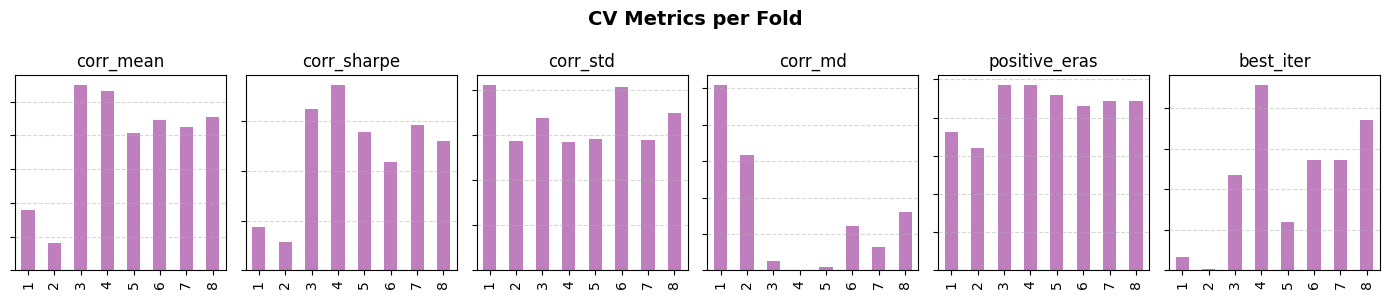

In [33]:
# Baseline Model with Large Params Numerai
model_name = 'baseline_cv'

baseline_params = {
    'n_estimators': 20000,
    'num_leaves': 64,
    'learning_rate': 0.001,
    'colsample_bytree': 0.1,
}

result = era_wise_cv(model_name, baseline_params, train_df=train, esr=200)

display(result['fold_results_df'])
plot_cv_metrics(result['fold_results_df'], COLS_FOLDS)

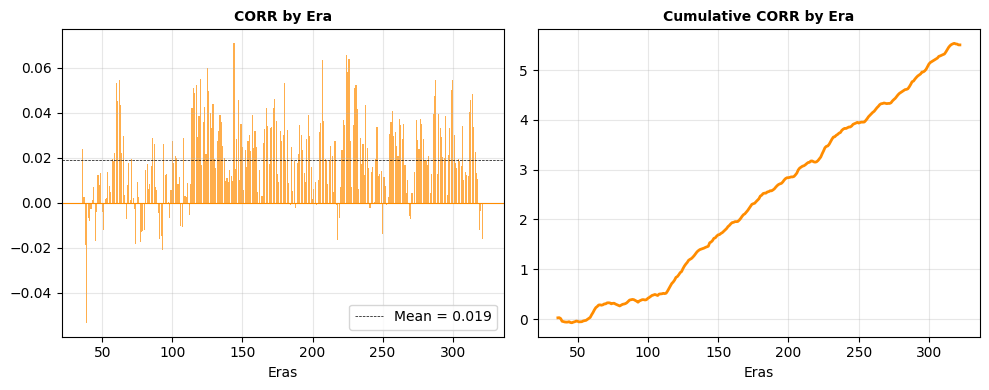

,model_name,time,corr_mean,corr_sharpe,corr_std,corr_md,autocorr,feature_exposure,positive_eras,bi_mean
0,baseline_cv,0:26:02,0.0192,1.0364,0.0185,0.102,0.9539,0.0732,0.7616,5748


In [35]:
plot_correlation_by_era(result['oof'])
# plot_prediction_target(oof)
# plot_feature_importance(importance_df)

model_results_df, model_results = log_model_result(model_results_df, model_results, result)
model_results_df[COLS_CV]

In [ ]:
# GIGACOD
Продолжаем участие в классическом турнире Numerai в блокноте Гугл Колаб.
1. Загрузил подготовленный датасет Train: (1627390 строк, 774 столбцов, 323 эры), Validation (3823506 строк, 775 столбцов, 616 эр)
2. Обучил модель 'baseline_cv' на 'train':
- параметры baseline_params из примеров Numerai,
- esr=200
- функция 'era_wise_cv' с использованием класса PurgedGroupTimeSeriesSplit(n_folds=8, purge=2, embargo=1),
- 'era_wise_cv' 2 датафрейма: 'fold_results_df' - результаты по фолдам и среднее по всем фолдам в последней строке, 'model_results_df' - результаты по всему OOF.
'fold_results_df':
	fold	train_eras	val_eras	corr_mean	corr_std	corr_sharpe	corr_md	positive_eras	best_iter
0	1	250-283	286-321	0.0090	0.0206	0.4363	0.1020	0.7222	653
1	2	250-319	322-357	0.0041	0.0144	0.2867	0.0636	0.6389	48
2	3	250-355	358-393	0.0275	0.0169	1.6212	0.0053	0.9722	4683
3	4	250-391	394-429	0.0265	0.0142	1.8675	0.0004	0.9722	9148
4	5	250-427	430-465	0.0204	0.0146	1.3938	0.0021	0.9167	2399
5	6	250-463	466-501	0.0222	0.0203	1.0929	0.0243	0.8611	5436
6	7	250-499	502-537	0.0212	0.0145	1.4656	0.0130	0.8889	5422
7	8	250-535	538-572	0.0227	0.0174	1.3016	0.0320	0.8857	7399
8	mean	-	-	0.0192	0.0166	1.1832	0.0303	0.8572	5748
'model_results_df':
	model_name	time	corr_mean	corr_sharpe	corr_std	corr_md	autocorr	feature_exposure	positive_eras	bi_mean
0	baseline_cv	0:26:02	0.0192	1.0364	0.0185	0.102	0.9539	0.0732	0.7616	5748
3. Запустил первую итерацию Optuna с помощью функции 'run_optuna_study' с 'pruner=optuna.pruners.MedianPruner(n_startup_trials=5,n_warmup_steps=2,interval_steps=1)
base_score = model_results['baseline_cv']['metrics']['corr_sharpe']
bi_mean = model_results['baseline_cv']['metrics']['bi_mean']
baseline_params = model_results['baseline_cv']['params']
def suggest_params(trial):
    return {
        'n_estimators': int(1.2 * bi_mean),
        'num_leaves': trial.suggest_int('num_leaves', 32, 128), 
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.01, log=True), 
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.05, 0.3), 
        'subsample': trial.suggest_float('subsample', 0.7, 1.0), 
        'subsample_freq': trial.suggest_int('subsample_freq', 1, 10), 
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 10.0), 
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 10.0)}
study, top_trials = run_optuna_study(
        train=train, 
        base_params=baseline_params, 
        base_score=base_score, 
        suggest_params=suggest_params,
        n_folds=5,
        n_trials=35,
        esr=200,
        top_trial=1)
И получил результаты:
number	value	params_colsample_bytree	params_learning_rate	params_num_leaves	params_reg_alpha	params_reg_lambda	params_subsample	params_subsample_freq	user_attrs_bi_mean
22	22	1.1181	0.1159	0.0021	54	9.3048	6.0249	0.9685	10	3394.0


4. Обучил модель 'tuned_cv_1' на 'train':
- параметры из лучшего триала,
- esr=200
- функция 'era_wise_cv' с использованием класса PurgedGroupTimeSeriesSplit(n_folds=8, purge=2, embargo=1),
'fold_results_df':
fold	train_eras	val_eras	corr_mean	corr_std	corr_sharpe	corr_md	positive_eras	best_iter
0	1	250-283	286-321	0.0135	0.0197	0.6841	0.0744	0.8333	768
1	2	250-319	322-357	0.0030	0.0101	0.2954	0.0298	0.6111	1
2	3	250-355	358-393	0.0304	0.0173	1.7528	0.0000	1.0000	3704
3	4	250-391	394-429	0.0313	0.0148	2.1101	0.0000	1.0000	5314
4	5	250-427	430-465	0.0211	0.0157	1.3487	0.0015	0.9444	1718
5	6	250-463	466-501	0.0249	0.0208	1.1970	0.0193	0.9167	3174
6	7	250-499	502-537	0.0242	0.0153	1.5784	0.0095	0.9167	3281
7	8	250-535	538-572	0.0221	0.0177	1.2487	0.0349	0.8857	3618
8	mean	-	-	0.0213	0.0164	1.2769	0.0212	0.8885	3468
'model_results_df':
model_name	time	corr_mean	corr_sharpe	corr_std	corr_md	autocorr	feature_exposure	positive_eras	bi_mean
0	baseline_cv	0:26:02	0.0192	1.0364	0.0185	0.1020	0.9539	0.0732	0.7616	5748
1	tuned_cv_1	0:22:22	0.0213	1.1308	0.0188	0.0744	0.9601	0.0715	0.7895	3468




Напиши сетку параметров для второй итерации Оптуна, учитывая результаты fold_results_df и model_results_df обоих моделей
В втором запсуке Оптуна мы будем использовать следующее:
- Фиксированный параметр 'n_estimators': int(1.2 * bi_mean) из era-wise-cv.
- Ранняя остановка
- функция 'run_optuna_study' с 'pruner=optuna.pruners.MedianPruner(n_startup_trials=5,n_warmup_steps=2,interval_steps=1 
- study = optuna.create_study(direction='maximize')
- study.enqueue_trial(параметры из 'tuned_cv_1')
- study.set_user_attr('base_score', base_score)
- в лучших практики Numerai на декабрь 2025 года.
- Не будем использовать max_depth






# 3. Optuna: Study 1

In [ ]:
# Optuna CV 'corr_sharpe' — the space around the 'baseline'

base_score = model_results['baseline_cv']['metrics']['corr_sharpe']
bi_mean = model_results['baseline_cv']['metrics']['bi_mean']
baseline_params = model_results['baseline_cv']['params']


def suggest_params(trial):
    return {
        'n_estimators': int(1.2 * bi_mean),
        'num_leaves': trial.suggest_int('num_leaves', 32, 128), 
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.01, log=True), 
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.05, 0.3), 
        'subsample': trial.suggest_float('subsample', 0.7, 1.0), 
        'subsample_freq': trial.suggest_int('subsample_freq', 1, 10), 
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 10.0), 
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 10.0), 
    }

study, top_trials = run_optuna_study(
        train=train, 
        base_params=baseline_params, 
        base_score=base_score, 
        suggest_params=suggest_params,
        n_folds=5,
        n_trials=35,
        esr=200,
        top_trial=1, 
)

# plot_param_importances(study)
# plot_optimization_history(study)

  0%|          | 0/35 [00:00<?, ?it/s]

Baseline: 1.0364
Best Optuna: 1.1181
Improvement: 0.0817


,number,value,params_colsample_bytree,params_learning_rate,params_num_leaves,params_reg_alpha,params_reg_lambda,params_subsample,params_subsample_freq,user_attrs_bi_mean
22,22,1.1181,0.1159,0.0021,54,9.3048,6.0249,0.9685,10,3394.0
29,29,1.1157,0.0902,0.0011,67,3.3011,1.5682,0.7448,6,6674.0
7,7,1.1145,0.0818,0.0011,116,8.5582,3.5074,0.7811,6,5699.0
8,8,1.1119,0.0908,0.0042,50,9.0218,7.6141,0.9937,9,2028.0
11,11,1.1100,0.0879,0.0020,45,9.9245,7.5801,0.8785,10,4565.0


# 4. Era-Wise CV: Tuned 1

,fold,train_eras,val_eras,corr_mean,corr_std,corr_sharpe,corr_md,positive_eras,best_iter
0,1,250-283,286-321,0.0135,0.0197,0.6841,0.0744,0.8333,768
1,2,250-319,322-357,0.0030,0.0101,0.2954,0.0298,0.6111,1
2,3,250-355,358-393,0.0304,0.0173,1.7528,0.0000,1.0000,3704
3,4,250-391,394-429,0.0313,0.0148,2.1101,0.0000,1.0000,5314
4,5,250-427,430-465,0.0211,0.0157,1.3487,0.0015,0.9444,1718
5,6,250-463,466-501,0.0249,0.0208,1.1970,0.0193,0.9167,3174
6,7,250-499,502-537,0.0242,0.0153,1.5784,0.0095,0.9167,3281
7,8,250-535,538-572,0.0221,0.0177,1.2487,0.0349,0.8857,3618
8,mean,-,-,0.0213,0.0164,1.2769,0.0212,0.8885,3468


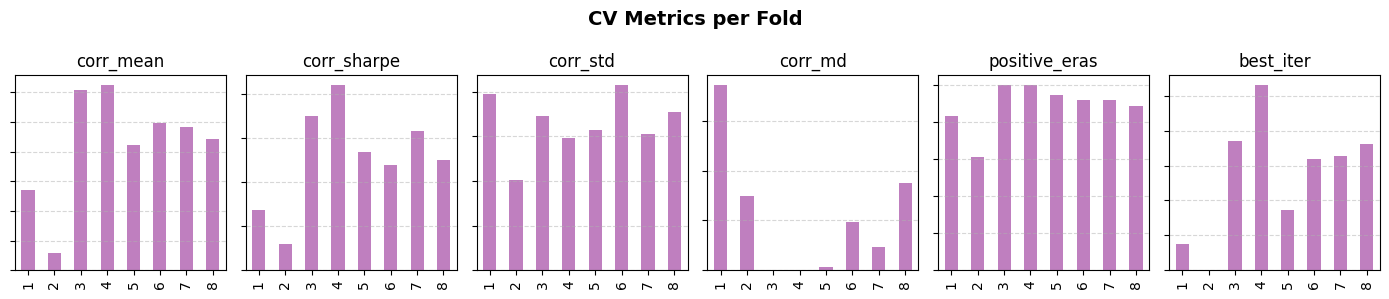

In [ ]:
# Tuned Model with Best Params from Study 1

model_name = 'tuned_cv_1'

# bi_mean = result['metrics']['bi_mean']
bi_mean = model_results['baseline_cv']['metrics']['bi_mean']

# params_tuned_1 = top_trials[0].params
params_tuned_1 = study['top_trials'][0].params
params_tuned_1.update({'n_estimators': int(1.2 * bi_mean)})

result = era_wise_cv(model_name, params_tuned_1, train, esr=200)

display(result['fold_results_df'])
plot_cv_metrics(result['fold_results_df'], COLS_FOLDS)

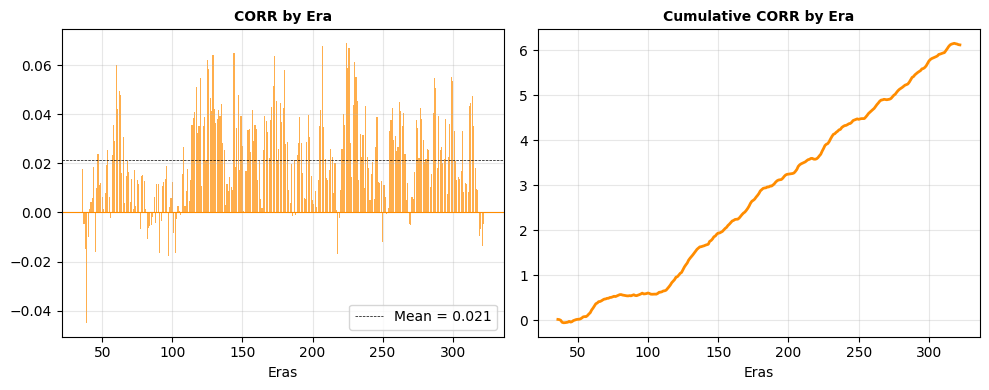

,model_name,time,corr_mean,corr_sharpe,corr_std,corr_md,autocorr,feature_exposure,positive_eras,bi_mean
0,baseline_cv,0:26:02,0.0192,1.0364,0.0185,0.1020,0.9539,0.0732,0.7616,5748
1,tuned_cv_1,0:22:22,0.0213,1.1308,0.0188,0.0744,0.9601,0.0715,0.7895,3468


In [ ]:
plot_correlation_by_era(result['oof'])

model_results_df, model_results = log_model_result(model_results_df, model_results, result)
model_results_df[COLS_CV]

# 5. Opuna: Study 2

In [25]:
# Optuna CV 'corr_sharpe' — the space around the 'params_tuned_1'

base_score = model_results['tuned_cv_1']['metrics']['corr_sharpe']
base_params = model_results['tuned_cv_1']['params']
bi_mean = model_results['tuned_cv_1']['metrics']['bi_mean']


def suggest_params(trial):
    return {
        'n_estimators': int(1.2 * bi_mean),
        'num_leaves': trial.suggest_int('num_leaves', 40, 100),          
        'learning_rate': trial.suggest_float('learning_rate', 0.0015, 0.008, log=True),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.08, 0.25),        
        'subsample': trial.suggest_float('subsample', 0.8, 1.0),                       
        'subsample_freq': trial.suggest_int('subsample_freq', 1, 7),                    
        'reg_alpha': trial.suggest_float('reg_alpha', 5.0, 15.0),                      
        'reg_lambda': trial.suggest_float('reg_lambda', 3.0, 12.0),                    
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 40, 100),            
        'feature_fraction_bynode': trial.suggest_float('feature_fraction_bynode', 0.1, 0.3) 
    }

study, top_trials = run_optuna_study(
        train=train, 
        base_params=base_params, 
        base_score=base_score, 
        suggest_params=suggest_params,
        n_folds=5,
        n_trials=50,
        esr=200,
        top_trial=2, 
)

# plot_param_importances(study)
# plot_optimization_history(study)

  0%|          | 0/50 [00:00<?, ?it/s]

Baseline: 1.1308
Best Optuna: 1.2307
Improvement: 0.0999


,number,value,params_colsample_bytree,params_feature_fraction_bynode,params_learning_rate,params_min_data_in_leaf,params_num_leaves,params_reg_alpha,params_reg_lambda,params_subsample,params_subsample_freq,user_attrs_bi_mean
40,40,1.2307,0.1094,0.2358,0.0040,46,63,9.0741,7.4127,0.8107,6,2847.0
24,24,1.1995,0.1440,0.2183,0.0049,71,80,10.0430,5.8560,0.8538,7,1828.0
41,41,1.1905,0.1119,0.2344,0.0038,47,61,7.9824,7.2863,0.8090,6,2515.0
28,28,1.1765,0.0998,0.2300,0.0047,71,79,11.2591,6.0504,0.8332,6,2156.0
25,25,1.1718,0.1530,0.2109,0.0047,56,82,10.0936,5.4234,0.8498,6,1851.0


<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

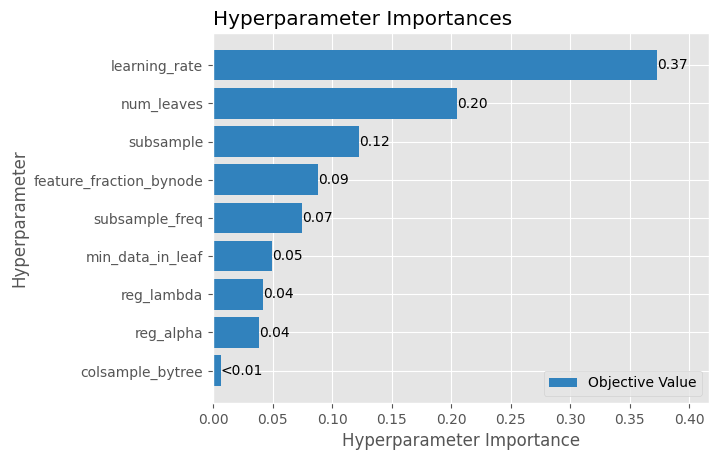

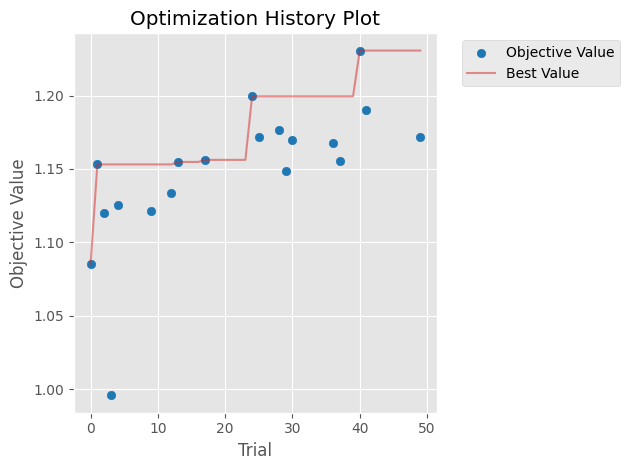

In [24]:
plot_param_importances(study)
plot_optimization_history(study)

In [ ]:
# results_to_save = {
#     'study': study,
#     'top_trials': top_trials,
#     'best_params': study.best_params,
#     'best_value': study.best_value,
#     'n_trials': len(study.trials),
#     'base_score': study.user_attrs.get('base_score') 
# }


# with open('/content/drive/MyDrive/Colab Notebooks/Step_1/study2.pkl', 'wb') as f:
#     pickle.dump(results_to_save, f)

# with open('/content/drive/MyDrive/Colab Notebooks/Step_1/model_results.pkl', 'rb') as f:
#     model_results_loaded = pickle.load(f)
# with open('/content/drive/MyDrive/Colab Notebooks/Step_1/study.pkl', 'rb') as f:
#     study = pickle.load(f)

# 6. Era-Wise CV: Tuned Top-2

In [25]:
# Tuned Model with Top-1 Params from Study 2

model_name = 'tuned_cv_21'

bi_mean = model_results['tuned_cv_1']['metrics']['bi_mean']

params_tuned_21 = study['top_trials'][0].params
params_tuned_21.update({'n_estimators': int(1.2 * bi_mean)})

result = era_wise_cv(model_name, params_tuned_21, train, esr=200)

model_results_df, model_results = log_model_result(model_results_df, model_results, result)

In [27]:
# Tuned Model with Top-2 Params from Study 2
model_name = 'tuned_cv_22'

bi_mean = model_results['tuned_cv_1']['metrics']['bi_mean']

params_tuned_22 = study['top_trials'][1].params
params_tuned_22.update({'n_estimators': int(1.2 * bi_mean)})

result = era_wise_cv(model_name, params_tuned_22, train, esr=200)

model_results_df, model_results = log_model_result(model_results_df, model_results, result)

tuned_cv_21


,fold,train_eras,val_eras,corr_mean,corr_std,corr_sharpe,corr_md,positive_eras,best_iter
0,1,250-283,286-321,0.0136,0.0183,0.7410,0.0703,0.8611,404
1,2,250-319,322-357,0.0070,0.0174,0.4015,0.0583,0.6389,2
2,3,250-355,358-393,0.0299,0.0196,1.5267,0.0013,0.9722,2161
3,4,250-391,394-429,0.0324,0.0153,2.1205,0.0000,1.0000,2640
4,5,250-427,430-465,0.0234,0.0165,1.4160,0.0024,0.9722,2061
5,6,250-463,466-501,0.0237,0.0199,1.1898,0.0272,0.8611,2371
6,7,250-499,502-537,0.0235,0.0159,1.4727,0.0153,0.8889,2023
7,8,250-535,538-572,0.0240,0.0158,1.5222,0.0129,0.9429,1654
8,mean,-,-,0.0222,0.0173,1.2988,0.0235,0.8922,2152


tuned_cv_22


,fold,train_eras,val_eras,corr_mean,corr_std,corr_sharpe,corr_md,positive_eras,best_iter
0,1,250-283,286-321,0.0149,0.0187,0.7961,0.0633,0.8611,493
1,2,250-319,322-357,0.0055,0.0172,0.3186,0.0963,0.6389,1
2,3,250-355,358-393,0.0280,0.0161,1.7409,0.0053,0.9722,1651
3,4,250-391,394-429,0.0316,0.0137,2.3071,0.0050,0.9722,1563
4,5,250-427,430-465,0.0246,0.0157,1.5642,0.0000,1.0000,1611
5,6,250-463,466-501,0.0246,0.0190,1.2914,0.0227,0.8889,1680
6,7,250-499,502-537,0.0247,0.0170,1.4499,0.0119,0.8889,1809
7,8,250-535,538-572,0.0237,0.0165,1.4368,0.0285,0.8857,1377
8,mean,-,-,0.0222,0.0167,1.3631,0.0291,0.8885,1615


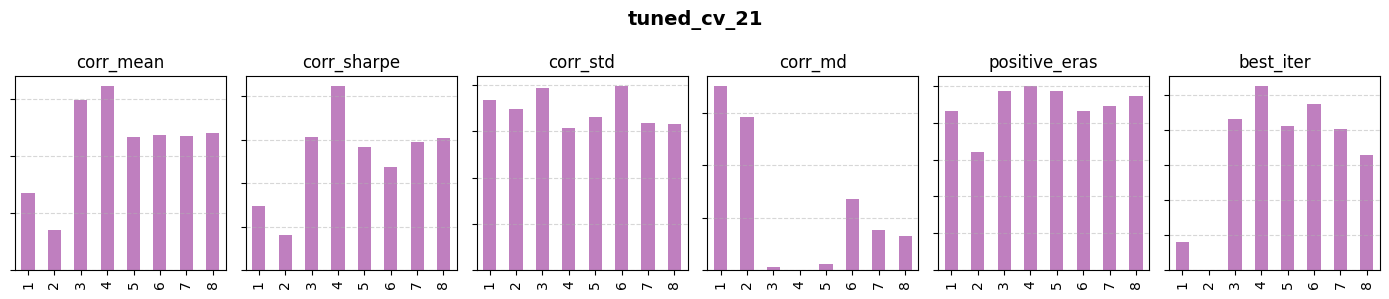

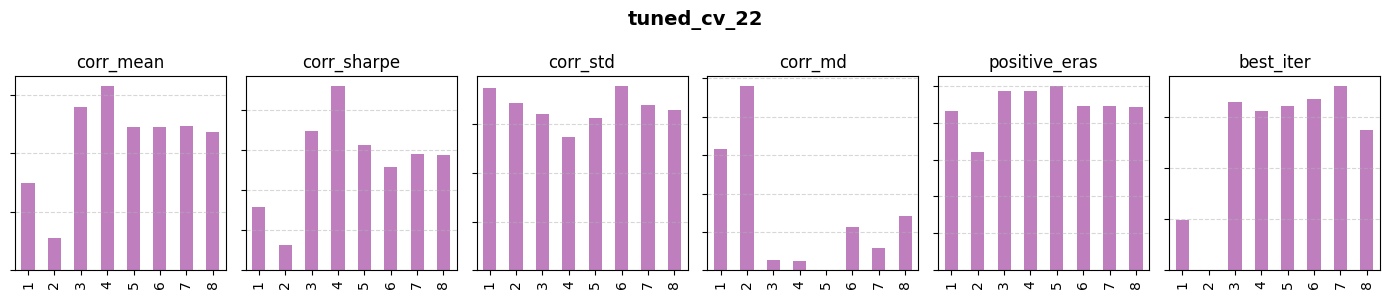

,model_name,time,corr_mean,corr_sharpe,corr_std,corr_md,autocorr,feature_exposure,positive_eras,bi_mean
0,baseline_cv,0:26:02,0.0192,1.0364,0.0185,0.1020,0.9539,0.0732,0.7616,5748
1,tuned_cv_1,0:22:22,0.0213,1.1308,0.0188,0.0744,0.9601,0.0715,0.7895,3468
2,tuned_cv_21,0:17:00,0.0222,1.1629,0.0191,0.0703,0.9624,0.0702,0.7926,2152
3,tuned_cv_22,0:15:54,0.0222,1.1987,0.0185,0.0963,0.9608,0.0710,0.7895,1615


In [28]:
model_name_21, model_name_22 = 'tuned_cv_21', 'tuned_cv_22'

print(model_name_21)
display(model_results[model_name_21]['fold_results_df'])
print(model_name_22)
display(model_results[model_name_22]['fold_results_df'])
plot_cv_metrics(model_results[model_name_21]['fold_results_df'], cols_folds=COLS_FOLDS, title=model_name_21)
plot_cv_metrics(model_results[model_name_22]['fold_results_df'], cols_folds=COLS_FOLDS, title=model_name_22)
model_results_df[COLS_CV]

In [ ]:
model_results

,num_step,model_type,model_name,target,estimate_type,time,corr_mean,corr_sharpe,corr_std,corr_md,mmc_mean,mmc_std,mmc_sharpe,mmc_md,autocorr,feature_exposure,positive_eras,bi_mean,-,num_leaves,learning_rate,colsample_bytree,subsample,subsample_freq,reg_alpha,reg_lambda,min_data_in_leaf,feature_fraction_bynode,n_estimators
0,1,LGBMRegressor,final_model_1,target,train_val,0:17:43,0.0213,1.3973,0.0152,0.1131,0.6284,0.0276,22.8072,0.0,0.9748,0.0555,0.9123,<NA>,NaN,63.0,0.003959,0.109362,0.810705,6.0,9.074066,7.412686,46.0,0.235764,8276.0


# 7. Final Model

In [22]:
# with open('/content/drive/MyDrive/Colab Notebooks/Step_1/model_results.pkl', 'rb') as f:
#     model_results = pickle.load(f)

# for k, v in model_results.items():
#     cols_meta = {
#         'model_name': model_results[k]['model_name'],
#         'model_type': MODEL_TYPE,
#         'target': model_results[k]['target'],
#         'estimate_type': model_results[k]['estimate_type'],
#         'time': model_results[k]['time'],
#         'num_step': NUM_STEP,
#     }

#     params = model_results[k]['params']
#     metrics = model_results[k]['metrics'].to_dict()
    
#     new_row = {**cols_meta, **metrics, **params}
#     model_results_df = pd.concat([model_results_df, pd.DataFrame([new_row])], ignore_index=True)

# model_results_df.drop(4, inplace=True)
# display(model_results_df)

In [ ]:
# with open('/content/drive/MyDrive/Colab Notebooks/Step_1/model_results.pkl', 'rb') as f:
#     model_results = pickle.load(f)

# k = 'tuned_cv_1'

# cols_meta = {
#     'model_name': model_results[k]['model_name'],
#     'model_type': MODEL_TYPE,
#     'target': model_results[k]['target'],
#     'estimate_type': model_results[k]['estimate_type'],
#     'time': model_results[k]['time'],
#     'num_step': NUM_STEP,
# }

# params = model_results[k]['params']
# metrics = model_results[k]['metrics'].to_dict()
    
# new_row = {**cols_meta, **metrics, **params}
# model_results_df = pd.concat([model_results_df, pd.DataFrame([new_row])], ignore_index=True)

# # model_results_df.drop(4, inplace=True)
# display(model_results_df)

In [15]:
with open('/content/drive/MyDrive/Colab Notebooks/Step_1/model_results.pkl', 'rb') as f:
    model_results = pickle.load(f)


bi_mean = model_results['tuned_cv_21']['params']['n_estimators']
params_final = model_results['tuned_cv_21']['params']
model_results.keys()
# del model_results
# gc.collect()

dict_keys(['baseline_cv', 'tuned_cv_1', 'tuned_cv_21', 'tuned_cv_22'])

In [16]:
model_name = 'final_model_1'

# bi_mean = model_results['tuned_cv_1']['params']['n_estimators']
# params_final = model_results['tuned_cv_21']['params']
# params_final.update({'n_estimators': int(1.2 * bi_mean)})

# params_final = params_tuned_21.copy()
# params_final = model_results['tuned_cv_21']['params']

results_val = train_validation(train, validation, params_final, model_name=model_name)

# model_results_df, model_results = log_model_result(model_results_df, model_results, results_val)
# display(model_results_df)

#plot_correlation_by_era(results_val['oof'])
#plot_mmc_by_era(results_val['oof'])
#plot_prediction_target(results_val['oof'])
#display(results_val['importance_df'].sort_values(ascending=False).head(20))

In [17]:
model_results_df1, model_results1 = log_model_result(model_results_df, model_results, results_val)
display(model_results_df1)

,num_step,model_type,model_name,target,estimate_type,time,corr_mean,corr_sharpe,corr_std,corr_md,mmc_mean,mmc_std,mmc_sharpe,mmc_md,autocorr,feature_exposure,positive_eras,bi_mean,-,autocorr_intra,autocorr_inter,num_leaves,learning_rate,colsample_bytree,subsample,subsample_freq,reg_alpha,reg_lambda,min_data_in_leaf,feature_fraction_bynode,n_estimators
0,1,LGBMRegressor,final_model_1,target,train_val,0:19:28,0.02113,1.367729,0.015449,0.121879,-0.003738,0.012013,-0.311205,0.244776,NaN,0.057324,0.920455,<NA>,NaN,-0.000938,0.9713,63.0,0.003959,0.109362,0.810705,6.0,9.074066,7.412686,46.0,0.235764,8276.0


In [19]:
with open('/content/drive/MyDrive/Colab Notebooks/Step_1/model_results1.pkl', 'wb') as f:
    pickle.dump(model_results1, f)

In [ ]:
model_name = 'final_model_1'

bi_mean = model_results['tuned_cv_21']['params']['n_estimators']
params_final = model_results['tuned_cv_21']['params']
# params_final.update({'n_estimators': int(1.2 * bi_mean)})

# params_final = params_tuned_21.copy()
# params_final = model_results['tuned_cv_21']['params']

results_val = train_validation(train, validation, params_final, model_name=model_name)

model_results_df, model_results = log_model_result(model_results_df, model_results, results_val)
display(model_results_df)

#plot_correlation_by_era(results_val['oof'])
#plot_mmc_by_era(results_val['oof'])
#plot_prediction_target(results_val['oof'])
#display(results_val['importance_df'].sort_values(ascending=False).head(20))

,num_step,model_type,model_name,target,estimate_type,time,corr_mean,corr_sharpe,corr_std,corr_md,mmc_mean,mmc_std,mmc_sharpe,mmc_md,autocorr,feature_exposure,positive_eras,bi_mean,-,n_estimators,num_leaves,learning_rate,colsample_bytree,subsample,subsample_freq,reg_alpha,reg_lambda,min_data_in_leaf,feature_fraction_bynode
0,1,LGBMRegressor,baseline_cv,target,train_cv,0:26:02,0.0192,1.0364,0.0185,0.1020,NaN,NaN,NaN,NaN,0.9539,0.0732,0.7616,5748,NaN,20000.0,64.0,0.001000,0.100000,NaN,NaN,NaN,NaN,NaN,NaN
1,1,LGBMRegressor,tuned_cv_1,target,train_cv,0:22:22,0.0213,1.1308,0.0188,0.0744,NaN,NaN,NaN,NaN,0.9601,0.0715,0.7895,3468,NaN,6897.0,54.0,0.002057,0.115921,0.968543,10.0,9.304847,6.024861,NaN,NaN
2,1,LGBMRegressor,tuned_cv_21,target,train_cv,0:17:00,0.0222,1.1629,0.0191,0.0703,NaN,NaN,NaN,NaN,0.9624,0.0702,0.7926,2152,NaN,8276.0,63.0,0.003959,0.109362,0.810705,6.0,9.074066,7.412686,46.0,0.235764
3,1,LGBMRegressor,tuned_cv_22,target,train_cv,0:15:54,0.0222,1.1987,0.0185,0.0963,NaN,NaN,NaN,NaN,0.9608,0.0710,0.7895,1615,NaN,4161.0,80.0,0.004940,0.144013,0.853801,7.0,10.042957,5.855953,71.0,0.218345
4,1,LGBMRegressor,final_model_1,target,train_val,0:18:05,0.0216,1.4712,0.0147,0.0877,-0.0024,0.0104,-0.231,0.1928,0.9708,0.0537,0.9237,<NA>,NaN,8276.0,63.0,0.003959,0.109362,0.810705,6.0,9.074066,7.412686,46.0,0.235764


,num_step,model_type,model_name,target,estimate_type,time,corr_mean,corr_sharpe,corr_std,corr_md,mmc_mean,mmc_std,mmc_sharpe,mmc_md,autocorr,feature_exposure,positive_eras,bi_mean,-,num_leaves,learning_rate,colsample_bytree,subsample,subsample_freq,reg_alpha,reg_lambda,min_data_in_leaf,feature_fraction_bynode,n_estimators
0,1,LGBMRegressor,final_model_1,target,train_val,0:17:43,0.0213,1.3973,0.0152,0.1131,0.6284,0.0276,22.8072,0.0,0.9748,0.0555,0.9123,<NA>,NaN,63.0,0.003959,0.109362,0.810705,6.0,9.074066,7.412686,46.0,0.235764,8276.0


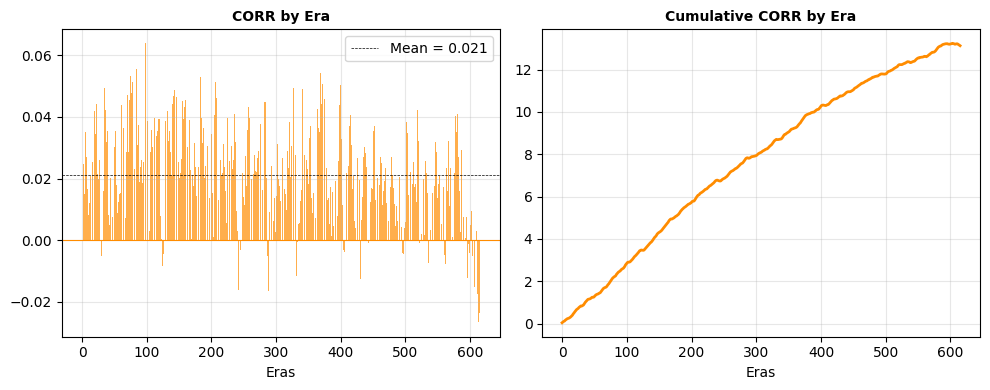

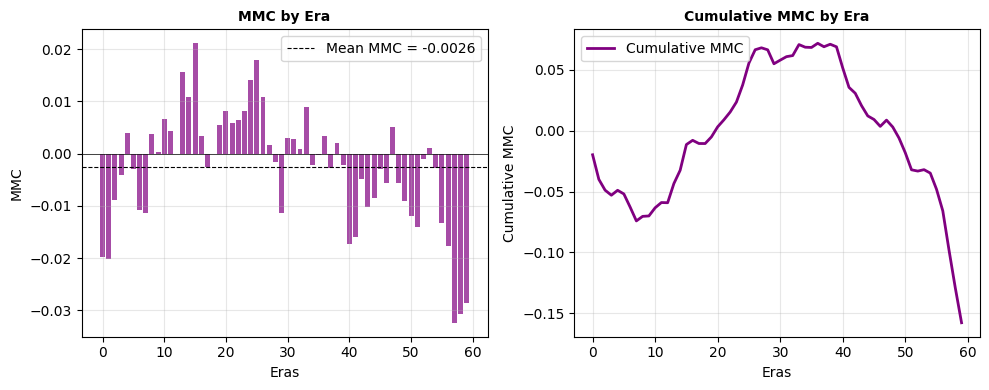

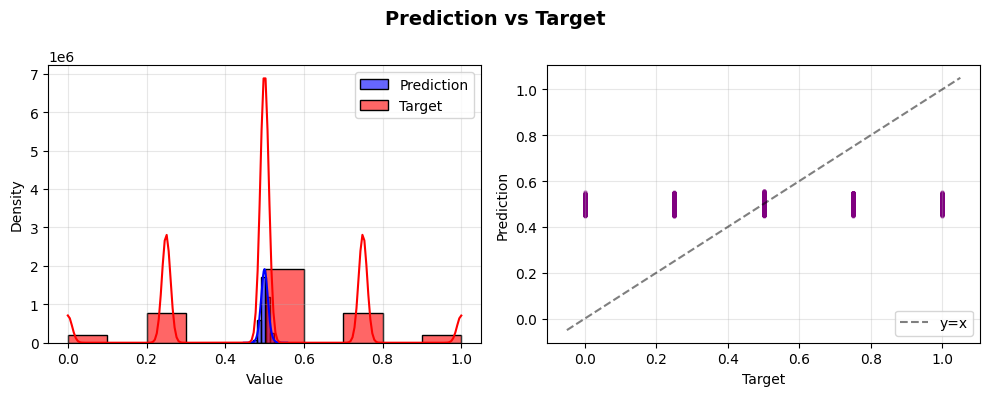

,gain
feature_simulated_shakiest_divisibility,1431.541380
feature_elusive_vapoury_accomplice,1427.450528
feature_bubbliest_tristichic_blizzard,1356.426526
feature_theosophical_tribal_dialectologist,1347.509916
feature_crinose_hardcover_confession,1324.427586
feature_military_nitpicking_reindustrialization,1306.961772
feature_overgreat_unblamed_hyperaemia,1278.759051
feature_supplicatory_ski_broach,1272.682675
feature_adorable_infernal_cartesianism,1269.192680
feature_straggly_gratulant_epizootic,1240.918165


In [38]:
model_name = 'final_model_1'

bi_mean = model_results['tuned_cv_1']['params']['n_estimators']
params_final = model_results['tuned_cv_21']['params']
params_final.update({'n_estimators': int(1.2 * bi_mean)})

# params_final = params_tuned_21.copy()
# params_final = model_results['tuned_cv_21']['params']

results_val = train_validation(train, validation, params_final, model_name=model_name)

model_results_df, model_results = log_model_result(model_results_df, model_results, results_val)
display(model_results_df)

plot_correlation_by_era(results_val['oof'])
plot_mmc_by_era(results_val['oof'])
plot_prediction_target(results_val['oof'])
display(results_val['importance_df'].sort_values(ascending=False).head(20))